# Published-image transfer case: BBBC039 nuclei

This exercise asks whether the **analysis mechanics** from the synthetic module
transfer to a published microscopy dataset. It does not reproduce the source
publication, estimate a drug effect, or validate a biological claim.

BBBC039 contains 200 single-channel, 16-bit fluorescence images of U2OS nuclei
and manually created instance masks. The dataset is CC0. Cite BBBC039 and the
Broad Bioimage Benchmark Collection when using it.

Source: https://bbbc.broadinstitute.org/BBBC039

## Learning objectives

After this exercise, a learner should be able to:

1. preserve intensity bit depth when loading microscopy images;
2. distinguish foreground-mask agreement from biological validity;
3. show how threshold and object-splitting choices alter measurements; and
4. keep image-level observations separate from treatment-level inference.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.segmentation import decode_color_instance_mask, load_grayscale_image
from src.sensitivity import SensitivityConfig, mask_iou, segment_with_config

DATA = ROOT / "data" / "external" / "BBBC039"
if not (DATA / "images").exists():
    raise FileNotFoundError(
        "BBBC039 is not present. From the repository root run: "
        "python scripts/download_bbbc039.py"
    )

## Select a small, declared sample

We use the first three filenames in the official **training** split. This is a
teaching sample, not a random sample of treatments and not an experimental
replicate structure. The validation and test splits remain untouched.

In [2]:
training_names = [
    line.strip() for line in (DATA / "metadata" / "training.txt").read_text().splitlines()
    if line.strip()
]
selected = training_names[:3]

records = []
for mask_name in selected:
    stem = Path(mask_name).stem
    image = load_grayscale_image(DATA / "images" / f"{stem}.tif")
    mask_rgba = np.asarray(Image.open(DATA / "masks" / mask_name))
    reference_labels = decode_color_instance_mask(mask_rgba)
    records.append({
        "image_id": stem,
        "image": image,
        "reference_labels": reference_labels,
    })

pd.DataFrame([
    {
        "image_id": row["image_id"],
        "shape": str(row["image"].shape),
        "dtype": str(row["image"].dtype),
        "intensity_min": int(row["image"].min()),
        "intensity_max": int(row["image"].max()),
        "derived_reference_objects": int(row["reference_labels"].max()),
    }
    for row in records
])

,image_id,shape,dtype,intensity_min,intensity_max,derived_reference_objects
0,IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...,"(520, 696)",uint16,122,1998,67
1,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,"(520, 696)",uint16,120,2224,112
2,IXMtest_A16_s3_w1032BE329-E21B-4E1B-B4B8-58700...,"(520, 696)",uint16,116,3409,95


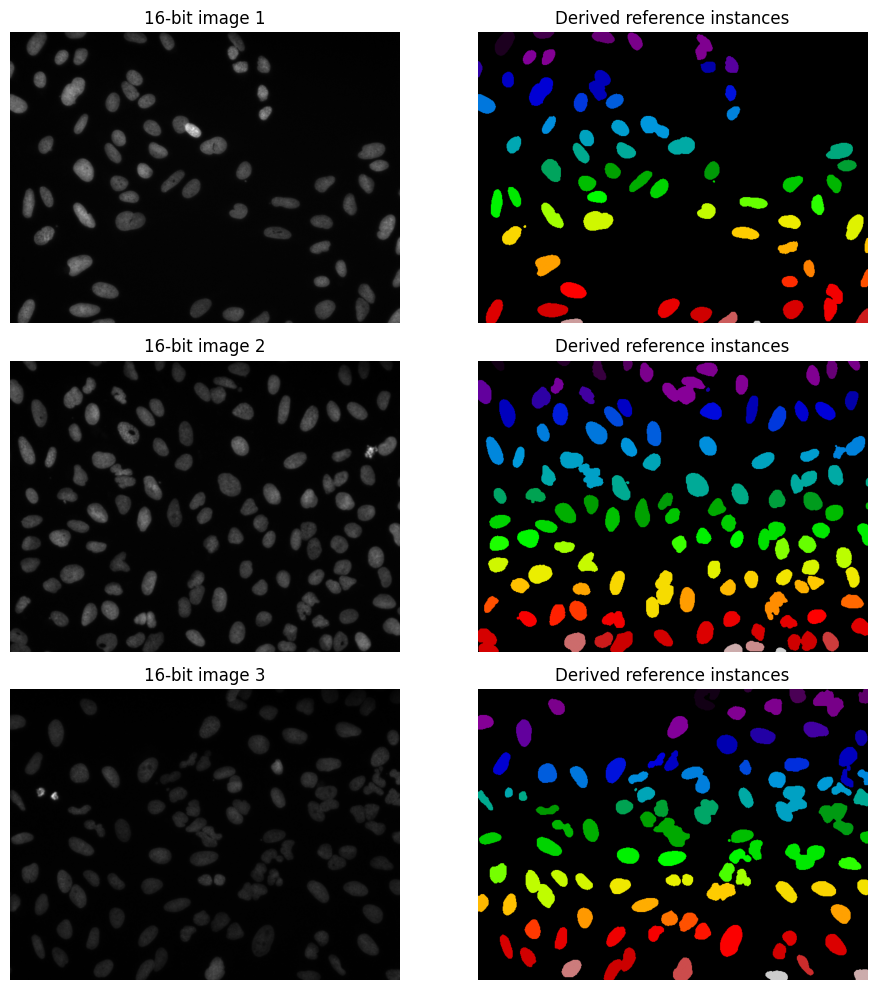

In [3]:
fig, axes = plt.subplots(len(records), 2, figsize=(10, 10))
for row_index, row in enumerate(records):
    axes[row_index, 0].imshow(row["image"], cmap="gray")
    axes[row_index, 0].set_title(f"16-bit image {row_index + 1}")
    axes[row_index, 1].imshow(row["reference_labels"], cmap="nipy_spectral")
    axes[row_index, 1].set_title("Derived reference instances")
    for axis in axes[row_index]:
        axis.axis("off")
plt.tight_layout()

## Operational comparison

The four configurations deliberately vary thresholding and splitting. Mask IoU
measures overlap with the published foreground mask. It is an **agreement
measure**, not proof that either mask represents biological truth.

In [4]:
configs = [
    SensitivityConfig("percentile_90", 1.0, 30, "percentile", 90, 40, 1),
    SensitivityConfig("percentile_95", 1.0, 30, "percentile", 95, 40, 1),
    SensitivityConfig("otsu_components", 1.0, 30, "otsu", None, 40, 1),
    SensitivityConfig("otsu_watershed", 1.0, 30, "otsu", None, 40, 1, "watershed"),
]

results = []
segmentations = {}
for row in records:
    reference_foreground = row["reference_labels"] > 0
    for config in configs:
        corrected, predicted_mask, predicted_labels, threshold = segment_with_config(
            row["image"], config
        )
        key = (row["image_id"], config.name)
        segmentations[key] = predicted_labels
        results.append({
            "image_id": row["image_id"],
            "configuration": config.name,
            "threshold": threshold,
            "mask_iou_agreement": mask_iou(predicted_mask, reference_foreground),
            "derived_reference_objects": int(row["reference_labels"].max()),
            "predicted_objects": int(predicted_labels.max()),
            "object_count_difference": int(predicted_labels.max() - row["reference_labels"].max()),
            "predicted_foreground_fraction": float(predicted_mask.mean()),
            "reference_foreground_fraction": float(reference_foreground.mean()),
        })

results_df = pd.DataFrame(results)
results_df.round(4)

,image_id,configuration,threshold,mask_iou_agreement,derived_reference_objects,predicted_objects,object_count_difference,predicted_foreground_fraction,reference_foreground_fraction
0,IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...,percentile_90,0.2206,0.7604,67,65,-2,0.0999,0.1303
1,IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...,percentile_95,0.3096,0.3800,67,51,-16,0.0496,0.1303
2,IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...,otsu_components,0.1543,0.9325,67,64,-3,0.1269,0.1303
3,IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...,otsu_watershed,0.1543,0.9325,67,143,76,0.1269,0.1303
4,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,percentile_90,0.2543,0.4203,112,92,-20,0.0993,0.2362
5,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,percentile_95,0.3063,0.2079,112,62,-50,0.0491,0.2362
6,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,otsu_components,0.1309,0.8977,112,105,-7,0.2184,0.2362
7,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,otsu_watershed,0.1309,0.8977,112,225,113,0.2184,0.2362
8,IXMtest_A16_s3_w1032BE329-E21B-4E1B-B4B8-58700...,percentile_90,0.1320,0.4807,95,85,-10,0.0995,0.2064
9,IXMtest_A16_s3_w1032BE329-E21B-4E1B-B4B8-58700...,percentile_95,0.1602,0.2357,95,60,-35,0.0488,0.2064


In [5]:
summary = (
    results_df.groupby("configuration", as_index=False)
    .agg(
        mean_mask_iou_agreement=("mask_iou_agreement", "mean"),
        mean_object_count_difference=("object_count_difference", "mean"),
        mean_predicted_foreground_fraction=("predicted_foreground_fraction", "mean"),
    )
)
summary.round(4)

,configuration,mean_mask_iou_agreement,mean_object_count_difference,mean_predicted_foreground_fraction
0,otsu_components,0.9084,-5.6667,0.1792
1,otsu_watershed,0.9084,104.3333,0.1792
2,percentile_90,0.5538,-10.6667,0.0996
3,percentile_95,0.2745,-33.6667,0.0492


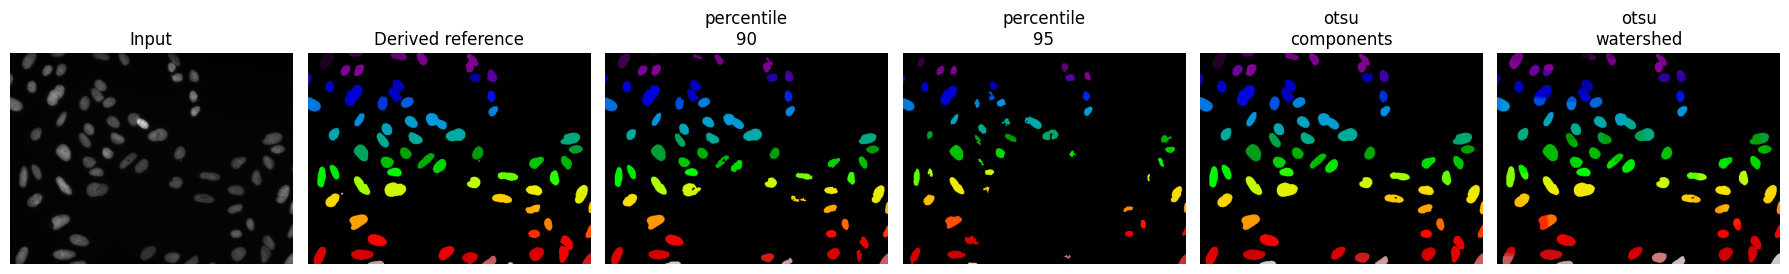

In [6]:
example = records[0]
fig, axes = plt.subplots(1, 2 + len(configs), figsize=(18, 4))
axes[0].imshow(example["image"], cmap="gray")
axes[0].set_title("Input")
axes[1].imshow(example["reference_labels"], cmap="nipy_spectral")
axes[1].set_title("Derived reference")
for index, config in enumerate(configs, start=2):
    axes[index].imshow(
        segmentations[(example["image_id"], config.name)], cmap="nipy_spectral"
    )
    axes[index].set_title(config.name.replace("_", "\n"))
for axis in axes:
    axis.axis("off")
plt.tight_layout()

## Interpretation exercise

Write one sentence for each prompt:

1. Which configuration agrees most closely with the published foreground mask?
2. Does the same configuration also recover a similar object count?
3. Which analytical decision appears most consequential in these examples?
4. What additional evidence would be needed before making a biological claim?

An acceptable conclusion is limited to these images and configurations, for
example: *foreground overlap and object counts changed with threshold and
splitting choices*. Do not infer compound effects, segmentation generalization,
or biological mechanisms from this three-image teaching sample.